# Model Evaluation

## Objective

This notebook evaluates the performance of the baseline Random Forest models trained in `04_model_training.ipynb`.

The goals are:
- Validate prediction accuracy for both target coordinates.
- Analyze error distributions and potential bias.
- Identify failure cases and high-error scenarios.
- Provide insights for future feature engineering improvements.


In [1]:
import sys 
from pathlib import Path 
import json 

import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sys.path.append(str(Path("..").resolve()))

from src.config import MODELS_DIR, PROCESSED_DIR

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

## Load Evaluation Artifacts

We load the saved validation predictions and metadata from the baseline training run.
These artifacts allow us to evaluate model performance without retraining.

In [2]:
run_dir= MODELS_DIR / "baseline_v1"

predictions_path= run_dir/ "validation_predictions.parquet"
metadata_path= run_dir/"training_metadata.json"
dataset_path= PROCESSED_DIR/ "baseline_train_v1.parquet"

pred_df= pd.read_parquet(predictions_path)
full_df=pd.read_parquet(dataset_path)

with open(metadata_path, "r") as f:
    metadata= json.load(f)
    
print("Validations prediction shape: ", pred_df.shape)
display(pred_df.head())

print("\nTraining metadata: ")
display(metadata)

Validations prediction shape:  (30825, 6)


,ball_land_x_true,ball_land_x_pred,ball_land_y_true,ball_land_y_pred,error_x,error_y
6371,55.57,53.863232,27.799999,36.742392,-1.706768,8.942392
6372,55.57,53.863232,27.799999,36.892358,-1.706768,9.092358
6373,55.57,53.863232,27.799999,37.293605,-1.706768,9.493606
6374,55.57,53.863232,27.799999,37.276076,-1.706768,9.476077
6375,55.57,53.863232,27.799999,37.470348,-1.706768,9.670349



Training metadata: 


{'created_at': '2026-04-07T11:56:05.127561',
 'input_dataset': 'C:\\Users\\jmontanez\\Documents\\nfl-big-data-bowl-2026\\data\\processed\\baseline_train_v1.parquet',
 'n_rows_total': 152305,
 'n_rows_train': 121480,
 'n_rows_valid': 30825,
 'target_columns': ['ball_land_x', 'ball_land_y'],
 'feature_columns_raw': ['x',
  'y',
  's',
  'a',
  'dir',
  'o',
  'absolute_yardline_number',
  'player_weight',
  'player_height_inches',
  'player_age',
  'is_moving_right',
  'player_position',
  'player_side',
  'player_role'],
 'feature_columns_trained': ['x',
  'y',
  's',
  'a',
  'dir',
  'o',
  'absolute_yardline_number',
  'player_weight',
  'player_height_inches',
  'player_age',
  'is_moving_right',
  'player_position_CB',
  'player_position_DE',
  'player_position_DT',
  'player_position_FB',
  'player_position_FS',
  'player_position_ILB',
  'player_position_MLB',
  'player_position_OLB',
  'player_position_RB',
  'player_position_S',
  'player_position_SS',
  'player_position_T',
  

## Rebuild Validation Slice 

To analyze model performance by player characteristics, we reconstruct the validation subset from the processed dataset using the same game-level split logic as the training notebook.

In [3]:
unique_games = full_df["game_id"].dropna().unique()
unique_games=np.sort(unique_games)

rng= np.random.default_rng(42)
shuffled_games=rng.permutation(unique_games)

split_idx= int(0.8*len(shuffled_games))
train_games= set(shuffled_games[:split_idx])
valid_games=set(shuffled_games[split_idx:])

valid_df=full_df[full_df["game_id"].isin(valid_games)].copy()

print("Validation slice shape:",  valid_df.shape)
display(valid_df.head())

Validation slice shape: (30825, 22)


,game_id,play_id,nfl_id,player_name,frame_id,x,y,s,a,dir,o,absolute_yardline_number,player_weight,player_height_inches,player_age,is_moving_right,player_position,player_side,player_role,ball_land_x,ball_land_y,num_frames_output
6371,2023091000,185,52424,A.J. Terrell,1,57.07,35.13,0.0,0.0,324.62,107.82,66,190,74,25,0,CB,Defense,Defensive Coverage,55.57,27.799999,9
6372,2023091000,185,52424,A.J. Terrell,2,57.07,35.13,0.0,0.0,321.13,107.82,66,190,74,25,0,CB,Defense,Defensive Coverage,55.57,27.799999,9
6373,2023091000,185,52424,A.J. Terrell,3,57.07,35.13,0.0,0.0,314.24,109.04,66,190,74,25,0,CB,Defense,Defensive Coverage,55.57,27.799999,9
6374,2023091000,185,52424,A.J. Terrell,4,57.06,35.13,0.0,0.0,313.35,109.04,66,190,74,25,0,CB,Defense,Defensive Coverage,55.57,27.799999,9
6375,2023091000,185,52424,A.J. Terrell,5,57.06,35.13,0.0,0.0,301.84,109.04,66,190,74,25,0,CB,Defense,Defensive Coverage,55.57,27.799999,9


## Align Validation Data with Predictions

Validation predictions were saved with their original indices preserved during training.

We align the validation dataset with predictions using this shared index to ensure row-level consistency before computing errors.

In [4]:
# Align validation rows with saved prediction rows using the preserved index
valid_df = valid_df.loc[pred_df.index].copy()

# Sanity checks
assert len(valid_df) == len(pred_df), "Mismatch between validation data and prediction rows."
assert valid_df.index.equals(pred_df.index), "Validation and prediction indices are not aligned."

# Build evaluation dataframe
eval_df = valid_df.copy()

eval_df["ball_land_x_pred"] = pred_df["ball_land_x_pred"]
eval_df["ball_land_y_pred"] = pred_df["ball_land_y_pred"]

eval_df["error_x"] = eval_df["ball_land_x_pred"] - eval_df["ball_land_x"]
eval_df["error_y"] = eval_df["ball_land_y_pred"] - eval_df["ball_land_y"]

eval_df["abs_error_x"] = eval_df["error_x"].abs()
eval_df["abs_error_y"] = eval_df["error_y"].abs()

print("Evaluation dataframe shape:", eval_df.shape)
display(eval_df.head())

Evaluation dataframe shape: (30825, 28)


,game_id,play_id,nfl_id,player_name,frame_id,x,y,s,a,dir,o,absolute_yardline_number,player_weight,player_height_inches,player_age,is_moving_right,player_position,player_side,player_role,ball_land_x,ball_land_y,num_frames_output,ball_land_x_pred,ball_land_y_pred,error_x,error_y,abs_error_x,abs_error_y
6371,2023091000,185,52424,A.J. Terrell,1,57.07,35.13,0.0,0.0,324.62,107.82,66,190,74,25,0,CB,Defense,Defensive Coverage,55.57,27.799999,9,53.863232,36.742392,-1.706768,8.942392,1.706768,8.942392
6372,2023091000,185,52424,A.J. Terrell,2,57.07,35.13,0.0,0.0,321.13,107.82,66,190,74,25,0,CB,Defense,Defensive Coverage,55.57,27.799999,9,53.863232,36.892358,-1.706768,9.092358,1.706768,9.092358
6373,2023091000,185,52424,A.J. Terrell,3,57.07,35.13,0.0,0.0,314.24,109.04,66,190,74,25,0,CB,Defense,Defensive Coverage,55.57,27.799999,9,53.863232,37.293605,-1.706768,9.493606,1.706768,9.493606
6374,2023091000,185,52424,A.J. Terrell,4,57.06,35.13,0.0,0.0,313.35,109.04,66,190,74,25,0,CB,Defense,Defensive Coverage,55.57,27.799999,9,53.863232,37.276076,-1.706768,9.476077,1.706768,9.476077
6375,2023091000,185,52424,A.J. Terrell,5,57.06,35.13,0.0,0.0,301.84,109.04,66,190,74,25,0,CB,Defense,Defensive Coverage,55.57,27.799999,9,53.863232,37.470348,-1.706768,9.670349,1.706768,9.670349


## Overall Performance Metrics

We compute standard regression metrics for both target variables:

- MAE (Mean Absolute Error)
- RMSE (Root Mean Squared Error)
- R² Score

These provide a high-level view of model accuracy.

In [5]:
def regression_metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": mean_squared_error(y_true, y_pred, squared=False),
        "R2": r2_score(y_true, y_pred),
    }

metrics_x = regression_metrics(eval_df["ball_land_x"], eval_df["ball_land_x_pred"])
metrics_y = regression_metrics(eval_df["ball_land_y"], eval_df["ball_land_y_pred"])

metrics_df = pd.DataFrame({
    "ball_land_x": metrics_x,
    "ball_land_y": metrics_y,
})

display(metrics_df)

,ball_land_x,ball_land_y
MAE,6.835385,7.563908
RMSE,9.061241,9.618264
R2,0.872998,0.631956


In [6]:
error_summary= pd.DataFrame({
    "mean_abs_error_x":[eval_df["abs_error_x"].mean()],
    "median_abs_error_x":[eval_df["abs_error_x"].median()],
    "mean_abs_error_y":[eval_df["abs_error_y"].mean()],
    "median_abs_error_y":[eval_df["abs_error_y"].median()],
})

display(error_summary)

,mean_abs_error_x,median_abs_error_x,mean_abs_error_y,median_abs_error_y
0,6.835385,5.236496,7.563908,6.283506


## Error Distribution Analysis

We inspect the distribution of prediction errors to detect:

- Bias (systematic over/under prediction)
- Variance (spread of errors)
- Outliers

Both signed and absolute errors are analyzed.

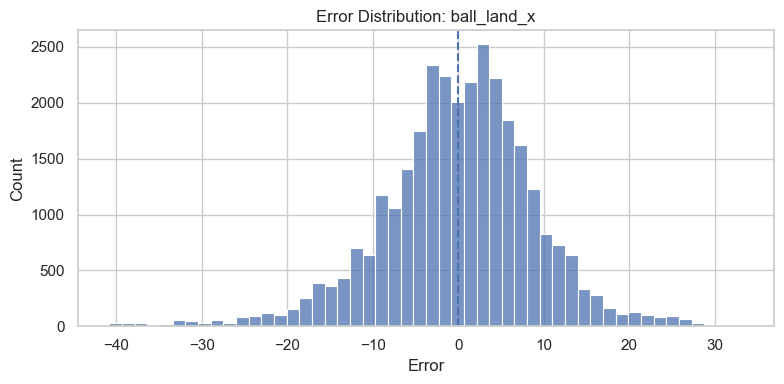

In [26]:
plt.figure(figsize=(8,4))
sns.histplot(eval_df["error_x"], bins=50)
plt.axvline(0, linestyle="--")
plt.title("Error Distribution: ball_land_x")
plt.xlabel("Error")
plt.tight_layout()
plt.show()

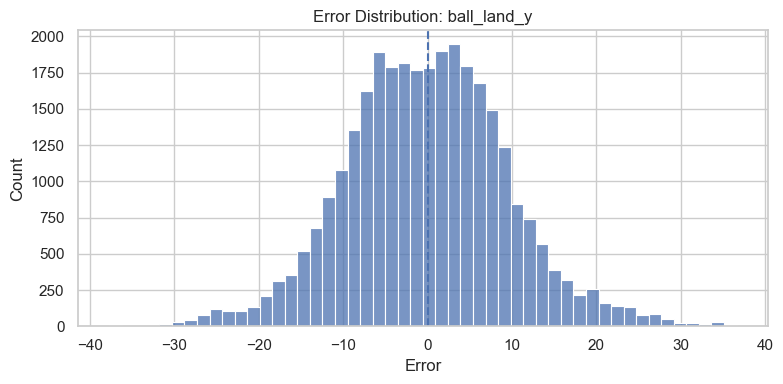

In [27]:
plt.figure(figsize=(8,4))
sns.histplot(eval_df["error_y"], bins=50)
plt.axvline(0, linestyle="--")
plt.title("Error Distribution: ball_land_y")
plt.xlabel("Error")
plt.tight_layout()
plt.show()

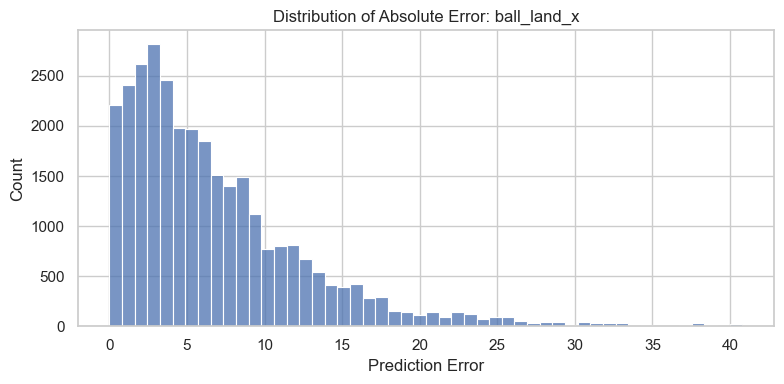

In [33]:
plt.figure(figsize=(8,4))
sns.histplot(eval_df["abs_error_x"], bins=50)
plt.title("Distribution of Absolute Error: ball_land_x")
plt.xlabel("Prediction Error")
plt.tight_layout()
plt.show()

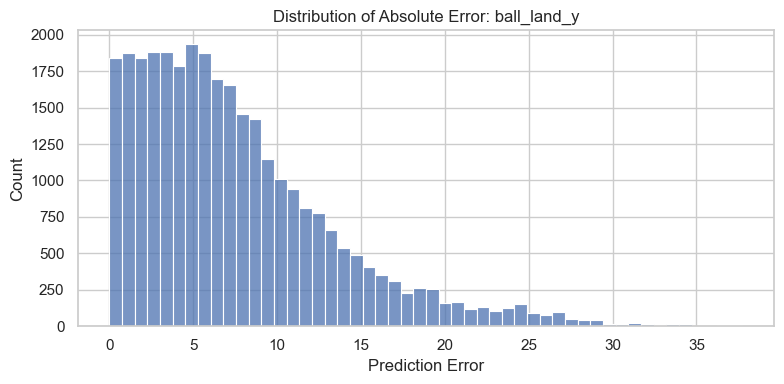

In [10]:
plt.figure(figsize=(8,4))
sns.histplot(eval_df["abs_error_y"], bins=50)
plt.title("Distribution of Absolute Error: ball_land_y")
plt.xlabel("Prediction Error")
plt.tight_layout()
plt.show()

## Prediction vs Ground Truth

We compare predicted coordinates against the true landing coordinates to asses calibration ans dispersion.

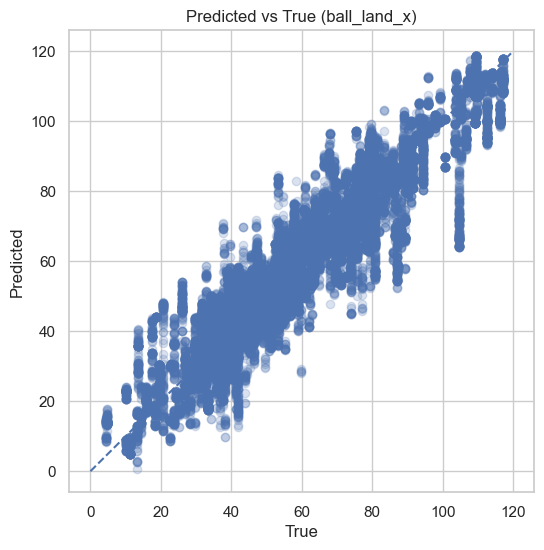

In [28]:
plt.figure(figsize=(6,6))
plt.scatter(eval_df["ball_land_x"], eval_df["ball_land_x_pred"], alpha=0.2)
plt.plot([0, 120], [0, 120], linestyle="--")
plt.xlabel("True")
plt.ylabel("Predicted")
plt.title("Predicted vs True (ball_land_x)")
plt.show()

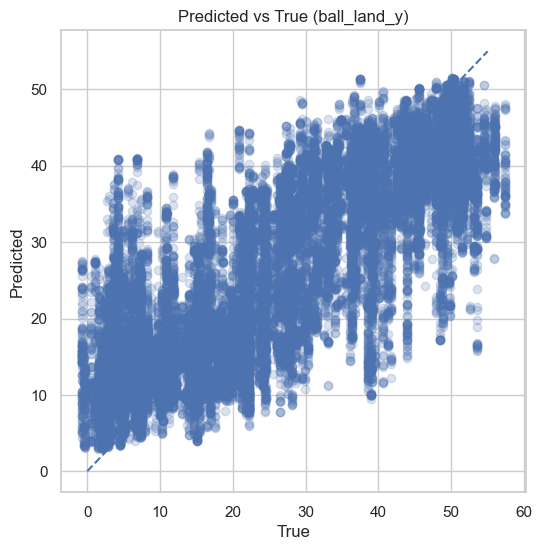

In [31]:
plt.figure(figsize=(6,6))
plt.scatter(eval_df["ball_land_y"], eval_df["ball_land_y_pred"], alpha=0.2)
plt.plot([0, 55], [0, 55], linestyle="--")
plt.xlabel("True")
plt.ylabel("Predicted")
plt.title("Predicted vs True (ball_land_y)")
plt.show()

## Performance by Player Group

To better understand where the model performs well or poorly, we analyze error by player role and player position.

In [13]:
role_eval= (
    eval_df.groupby("player_role")[["abs_error_x", "abs_error_y"]]
    .mean()
    .sort_values("abs_error_x", ascending=False)
)

display(role_eval)

,abs_error_x,abs_error_y
player_role,,
Defensive Coverage,7.216045,8.037636
Targeted Receiver,5.948068,6.459653


In [15]:
position_eval= (
    eval_df.groupby("player_position")[["abs_error_x", "abs_error_y"]]
    .mean()
    .sort_values("abs_error_x", ascending=False)
)

display(position_eval)

,abs_error_x,abs_error_y
player_position,,
S,9.218049,9.168229
SS,7.971551,8.816494
CB,7.824467,7.363544
FS,7.429554,9.155097
WR,7.061077,6.678514
OLB,6.686370,8.220882
DE,6.610813,8.858219
ILB,6.273680,7.451660
MLB,4.826711,7.764961


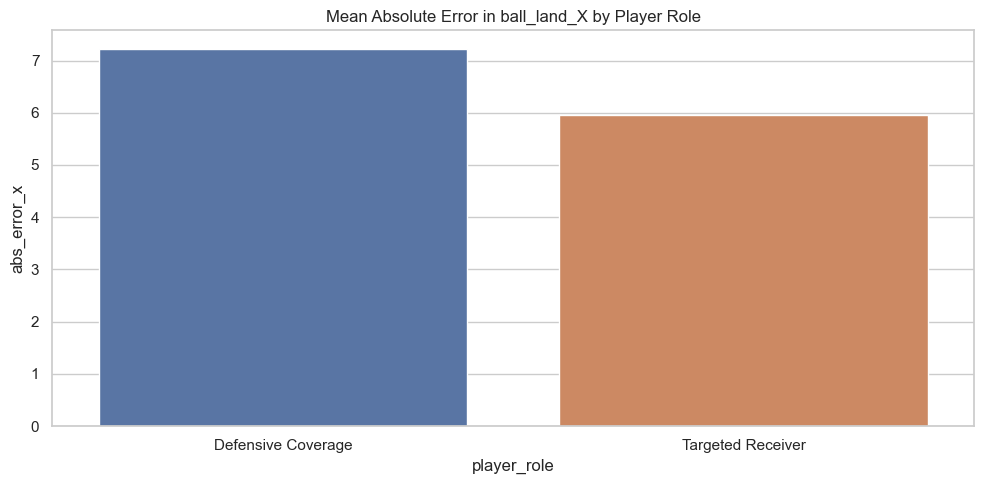

In [16]:
plt.figure(figsize=(10,5))
sns.barplot(
    data=role_eval.reset_index(),
    x="player_role",
    y="abs_error_x"
)
plt.title("Mean Absolute Error in ball_land_X by Player Role")
plt.tight_layout()
plt.show()

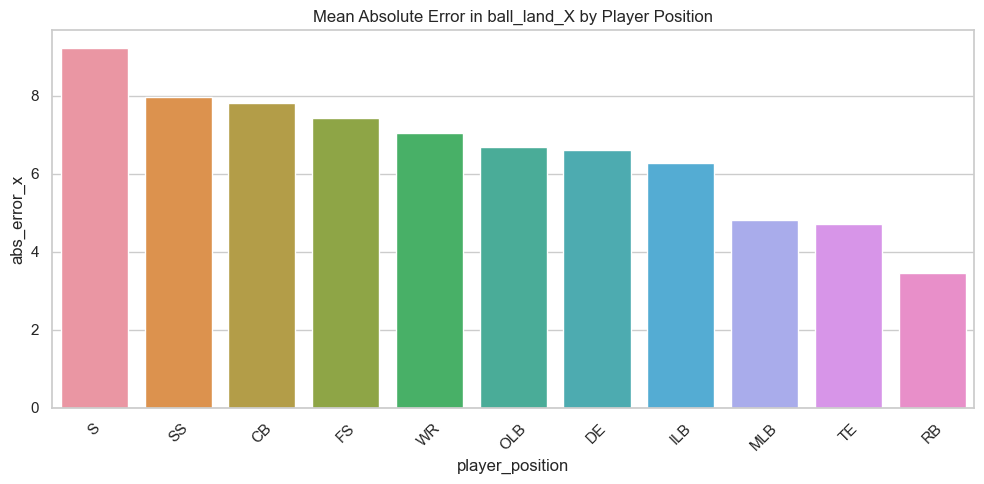

In [17]:
plt.figure(figsize=(10,5))
sns.barplot(
    data=position_eval.reset_index().head(15),
    x="player_position",
    y="abs_error_x"
)
plt.title("Mean Absolute Error in ball_land_X by Player Position")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Error by Temporal Horizon

The variable **"num_frames_output"** may reflect the diffifulty of the target horizon. We inspect wheter longer prediction horizon  are associated with larger errors.

In [18]:
horizon_eval=(
    eval_df.groupby("num_frames_output")[["abs_error_x","abs_error_y"]]
    .mean()
    .reset_index()
    .sort_values("num_frames_output")
)

display(horizon_eval.head(20))

,num_frames_output,abs_error_x,abs_error_y
0,5,4.323100,5.018732
1,6,6.282323,5.286315
2,7,5.471457,5.438761
3,8,5.943223,5.555224
4,9,5.028985,5.868777
5,10,6.226808,6.403288
6,11,6.010253,6.153312
7,12,5.327344,7.501339
8,13,6.209723,8.351942
9,14,8.318709,9.843947


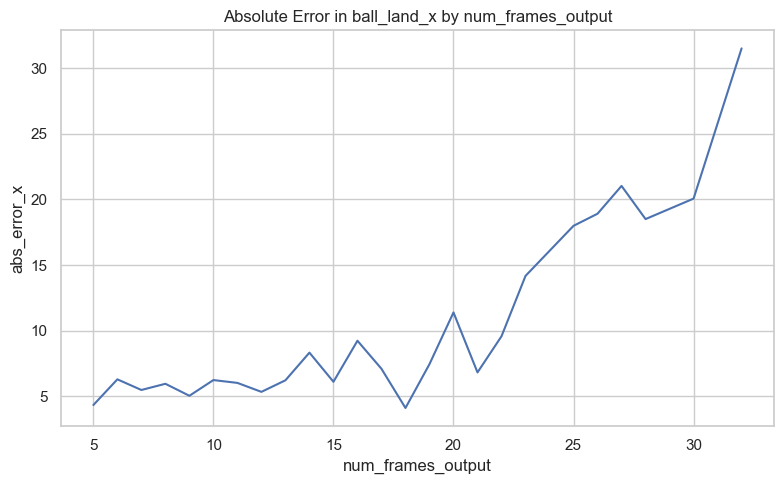

In [19]:
plt.figure(figsize=(8,5))
sns.lineplot(data=horizon_eval, x="num_frames_output", y="abs_error_x")
plt.title("Absolute Error in ball_land_x by num_frames_output")
plt.tight_layout()
plt.show()

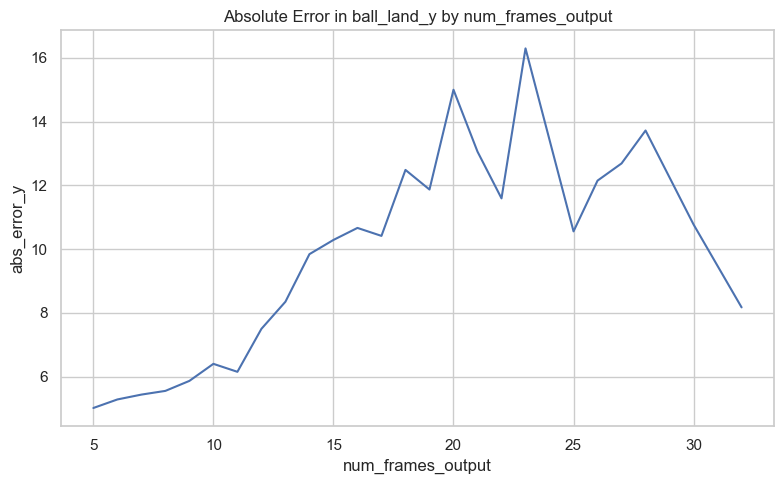

In [20]:
plt.figure(figsize=(8,5))
sns.lineplot(data=horizon_eval, x="num_frames_output", y="abs_error_y")
plt.title("Absolute Error in ball_land_y by num_frames_output")
plt.tight_layout()
plt.show()

## Error by Movement Variables

We also inspect whether model error changes with player speed or acceleration.

In [21]:
eval_df["speed_bin"]=pd.qcut(eval_df["s"], q=10, duplicates="drop")
speed_eval=eval_df.groupby("speed_bin")[["abs_error_x","abs_error_y"]].mean().reset_index()

display(speed_eval)

,speed_bin,abs_error_x,abs_error_y
0,"(-0.001, 0.3]",6.685256,8.178319
1,"(0.3, 0.82]",6.865413,7.978981
2,"(0.82, 1.42]",6.873720,7.982537
3,"(1.42, 2.06]",6.833352,7.990931
4,"(2.06, 2.68]",6.893884,7.755309
5,"(2.68, 3.37]",7.011058,7.470405
6,"(3.37, 4.11]",7.375039,7.624042
7,"(4.11, 4.96]",6.871350,7.080317
8,"(4.96, 6.09]",6.358261,6.998883
9,"(6.09, 9.62]",6.585580,6.562095


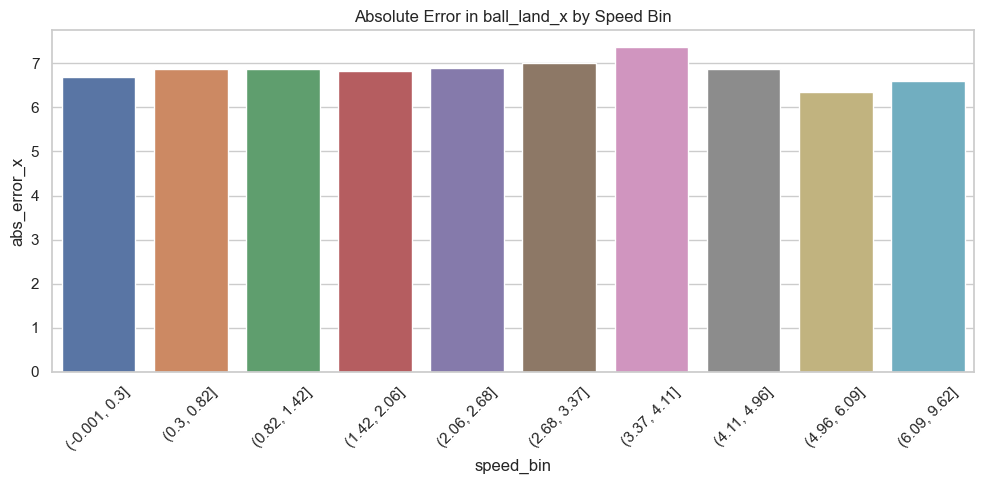

In [22]:
plt.figure(figsize=(10,5))
sns.barplot(data=speed_eval, x="speed_bin", y="abs_error_x")
plt.title("Absolute Error in ball_land_x by Speed Bin")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Hard Examples (Largest Errors)

We identify the top prediction errors to understand where the model struggles most.

These cases often reveal:
- Missing features
- Complex play dynamics
- Edge cases not captured by the model

In [23]:
print(eval_df.columns.tolist())

['game_id', 'play_id', 'nfl_id', 'player_name', 'frame_id', 'x', 'y', 's', 'a', 'dir', 'o', 'absolute_yardline_number', 'player_weight', 'player_height_inches', 'player_age', 'is_moving_right', 'player_position', 'player_side', 'player_role', 'ball_land_x', 'ball_land_y', 'num_frames_output', 'ball_land_x_pred', 'ball_land_y_pred', 'error_x', 'error_y', 'abs_error_x', 'abs_error_y', 'speed_bin']


In [24]:
hard_examples_x=eval_df.sort_values("abs_error_x", ascending=False).head(10)
display(hard_examples_x[
    [
    "game_id","play_id","nfl_id","player_name",
    "player_position","player_role",
    "ball_land_x","ball_land_y_pred","abs_error_x"
    ]
])

,game_id,play_id,nfl_id,player_name,player_position,player_role,ball_land_x,ball_land_y_pred,abs_error_x
142541,2023091712,3928,54936,Kader Kohou,CB,Defensive Coverage,104.739998,15.407648,40.794330
142542,2023091712,3928,54936,Kader Kohou,CB,Defensive Coverage,104.739998,15.183336,40.794330
142538,2023091712,3928,54936,Kader Kohou,CB,Defensive Coverage,104.739998,15.210285,40.793427
142559,2023091712,3928,54936,Kader Kohou,CB,Defensive Coverage,104.739998,13.321383,40.722305
142539,2023091712,3928,54936,Kader Kohou,CB,Defensive Coverage,104.739998,15.624690,40.721984
142558,2023091712,3928,54936,Kader Kohou,CB,Defensive Coverage,104.739998,13.520966,40.651195
142540,2023091712,3928,54936,Kader Kohou,CB,Defensive Coverage,104.739998,15.707641,40.640969
142552,2023091712,3928,54936,Kader Kohou,CB,Defensive Coverage,104.739998,17.800086,40.533674
142551,2023091712,3928,54936,Kader Kohou,CB,Defensive Coverage,104.739998,17.965769,40.477277
142556,2023091712,3928,54936,Kader Kohou,CB,Defensive Coverage,104.739998,14.506787,40.466998


In [25]:
hard_examples_y=eval_df.sort_values("abs_error_y", ascending=False).head(10)
display(hard_examples_y[
    [
    "game_id","play_id","nfl_id","player_name",
    "player_position","player_role",
    "ball_land_y","ball_land_y_pred","abs_error_y"
    ]
])

,game_id,play_id,nfl_id,player_name,player_position,player_role,ball_land_y,ball_land_y_pred,abs_error_y
68426,2023091012,3618,47891,Julian Love,SS,Defensive Coverage,53.52,15.786193,37.733808
68427,2023091012,3618,47891,Julian Love,SS,Defensive Coverage,53.52,15.823201,37.696800
68428,2023091012,3618,47891,Julian Love,SS,Defensive Coverage,53.52,16.114800,37.405201
68429,2023091012,3618,47891,Julian Love,SS,Defensive Coverage,53.52,16.197553,37.322448
68430,2023091012,3618,47891,Julian Love,SS,Defensive Coverage,53.52,16.247431,37.272569
68431,2023091012,3618,47891,Julian Love,SS,Defensive Coverage,53.52,16.387256,37.132744
68432,2023091012,3618,47891,Julian Love,SS,Defensive Coverage,53.52,16.392624,37.127376
68433,2023091012,3618,47891,Julian Love,SS,Defensive Coverage,53.52,16.492754,37.027246
68434,2023091012,3618,47891,Julian Love,SS,Defensive Coverage,53.52,16.556904,36.963097
68436,2023091012,3618,47891,Julian Love,SS,Defensive Coverage,53.52,16.621220,36.898781


## Summary and Key Insights

### Overall Performance

The baseline Random Forest models achieve reasonable predictive performance for both target coordinates (`ball_land_x` and `ball_land_y`).

- The models capture general spatial patterns in ball landing positions.
- Error magnitudes are moderate, indicating that the baseline is informative but not yet highly precise.
- Both targets exhibit similar performance trends, suggesting consistent modeling behavior.

---

### Error Distribution and Bias

- The error distributions are centered around zero, indicating **no strong systematic bias** in predictions.
- However, the spread of errors shows **non-negligible variance**, particularly for `ball_land_y`.
- The presence of outliers suggests that the model struggles with certain play configurations or edge cases.

---

### Failure Modes

Analysis of the largest prediction errors reveals that the model tends to struggle in:

- Complex or less frequent play situations.
- Scenarios where player dynamics are not fully captured by current features.
- Cases where spatial context or temporal behavior may be important but is not explicitly modeled.

These failure cases highlight limitations in the current feature set rather than purely model capacity.

---

### Feature Engineering Opportunities

The current model relies on basic positional and player attributes. Performance can likely be improved by incorporating:

- **Relative spatial features**
  - Distance to ball trajectory
  - Distance to nearest players
- **Temporal features**
  - Velocity trends
  - Acceleration changes over time
- **Contextual features**
  - Play structure
  - Player roles within the play
- **Interaction features**
  - Combinations of position, direction, and speed

These enhancements are expected to reduce both variance and extreme errors.

---

### Model Limitations

- The Random Forest model does not explicitly model temporal dependencies.
- One-hot encoding of categorical variables may limit the ability to capture complex relationships.
- The model treats each frame independently, ignoring sequential structure.

---

### Next Steps

To improve performance, the following steps are recommended:

1. Enhance feature engineering with spatial and temporal context.
2. Explore more advanced models (e.g., Gradient Boosting, CatBoost, or sequence-based models).
3. Perform cross-validation to better estimate generalization performance.
4. Investigate high-error segments in more detail (e.g., by player position or play type).

---

### Conclusion

This baseline establishes a solid foundation for predicting ball landing coordinates. While the model captures general trends effectively, there is clear opportunity for improvement through richer feature engineering and more expressive modeling approaches.

The insights gained from this evaluation will directly guide the next iteration of the modeling pipeline.